# DeBERTa-v3 for `discourse_effectiveness` — Upgraded Pipeline

**Changes from the DistilBERT baseline:**
1. Model: `distilbert-base-uncased` → `microsoft/deberta-v3-base`
2. Input: simple string concat → **sentence-pair encoding** (discourse_type as Sentence A, discourse_text as Sentence B)
3. Loss: class-weighted CrossEntropy → **Focal Loss** (better for hard/minority examples)
4. Epochs: 3 → 5 (DeBERTa needs more warmup)
5. Max length: 128 → 256 (discourse_text can be long)
6. Post-training: **threshold calibration** on validation set to boost Ineffective recall


In [1]:
!pip install -U transformers datasets accelerate scikit-learn pandas torch matplotlib seaborn


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
!pip uninstall torchvision -y

In [4]:
!pip uninstall torch torchvision torchaudio transformers -y
!pip install torch torchaudio --index-url https://download.pytorch.org/whl/cu121
!pip install transformers datasets accelerate scikit-learn pandas numpy matplotlib seaborn sentencepiece

Found existing installation: torch 2.11.0
Uninstalling torch-2.11.0:
  Successfully uninstalled torch-2.11.0
Found existing installation: transformers 5.6.2
Uninstalling transformers-5.6.2:
  Successfully uninstalled transformers-5.6.2


Looking in indexes: https://download.pytorch.org/whl/cu121


ERROR: Could not find a version that satisfies the requirement torch (from versions: none)

[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for torch


  Using cached transformers-5.6.2-py3-none-any.whl.metadata (33 kB)
  Using cached torch-2.11.0-cp314-cp314-win_amd64.whl.metadata (29 kB)
Using cached transformers-5.6.2-py3-none-any.whl (10.4 MB)
Using cached torch-2.11.0-cp314-cp314-win_amd64.whl (114.6 MB)

   ---------------------------------------- 0/2 [torch]
   ---------------------------------------- 0/2 [torch]
   ---------------------------------------- 0/2 [torch]
   ---------------------------------------- 0/2 [torch]
   ---------------------------------------- 0/2 [torch]
   ---------------------------------------- 0/2 [torch]
   ---------------------------------------- 0/2 [torch]
   ---------------------------------------- 0/2 [torch]
   ---------------------------------------- 0/2 [torch]
   ---------------------------------------- 0/2 [torch]
   ---------------------------------------- 0/2 [torch]
   ---------------------------------------- 0/2 [torch]
   ---------------------------------------- 0/2 [torch]
   -------


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
!pip uninstall torch torchvision torchaudio transformers datasets accelerate -y

Found existing installation: torch 2.11.0
Uninstalling torch-2.11.0:
  Successfully uninstalled torch-2.11.0
Found existing installation: transformers 5.6.2
Uninstalling transformers-5.6.2:
  Successfully uninstalled transformers-5.6.2
Found existing installation: datasets 4.8.5
Uninstalling datasets-4.8.5:
  Successfully uninstalled datasets-4.8.5
Found existing installation: accelerate 1.13.0
Uninstalling accelerate-1.13.0:
  Successfully uninstalled accelerate-1.13.0


In [10]:
import sys
print(sys.executable)

C:\Users\chtou\bert_env_311\Scripts\python.exe


In [11]:
import sys

!{sys.executable} -m pip install --upgrade pip
!{sys.executable} -m pip uninstall torch torchvision torchaudio transformers datasets accelerate tokenizers -y
!{sys.executable} -m pip install torch torchaudio
!{sys.executable} -m pip install transformers==4.41.2 datasets accelerate scikit-learn pandas numpy matplotlib seaborn sentencepiece

   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ----------- ---------------------------- 0.5/1.8 MB 2.4 MB/s eta 0:00:01
   ----------------------- ---------------- 1.0/1.8 MB 2.4 MB/s eta 0:00:01
   ---------------------------------- ----- 1.6/1.8 MB 2.4 MB/s eta 0:00:01
   ---------------------------------------- 1.8/1.8 MB 2.2 MB/s  0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 26.0.1
    Uninstalling pip-26.0.1:
      Successfully uninstalled pip-26.0.1
Found existing installation: torch 2.7.1+cu118
Uninstalling torch-2.7.1+cu118:
  Successfully uninstalled torch-2.7.1+cu118
Found existing installation: torchvision 0.22.1+cu118
Uninstalling torchvision-0.22.1+cu118:
  Successfully uninstalled torchvision-0.22.1+cu118
Found existing installation: torchaudio 2.5.1+cu121
Uninstalling torchaudio-2.5.1+cu121:
  Successfully uninstalled torchaudio-2.5.1+cu121
Found exis

You can safely remove it manually.


   ---------------------------------------- 0.0/114.5 MB ? eta -:--:--
   ---------------------------------------- 0.3/114.5 MB ? eta -:--:--
   ---------------------------------------- 0.8/114.5 MB 2.4 MB/s eta 0:00:48
   ---------------------------------------- 1.3/114.5 MB 2.4 MB/s eta 0:00:48
    --------------------------------------- 1.6/114.5 MB 2.4 MB/s eta 0:00:48
    --------------------------------------- 2.1/114.5 MB 2.4 MB/s eta 0:00:47
    --------------------------------------- 2.6/114.5 MB 2.4 MB/s eta 0:00:48
   - -------------------------------------- 3.1/114.5 MB 2.4 MB/s eta 0:00:47
   - -------------------------------------- 3.7/114.5 MB 2.4 MB/s eta 0:00:47
   - -------------------------------------- 4.2/114.5 MB 2.4 MB/s eta 0:00:47
   - -------------------------------------- 4.5/114.5 MB 2.4 MB/s eta 0:00:47
   - -------------------------------------- 5.0/114.5 MB 2.4 MB/s eta 0:00:47
   - -------------------------------------- 5.5/114.5 MB 2.4 MB/s eta 0:00:47


In [3]:
import sys

!{sys.executable} -m pip uninstall torch torchaudio -y
!{sys.executable} -m pip install torch torchaudio --index-url https://download.pytorch.org/whl/cu121

Found existing installation: torch 2.11.0
Uninstalling torch-2.11.0:
  Successfully uninstalled torch-2.11.0
Found existing installation: torchaudio 2.11.0
Uninstalling torchaudio-2.11.0:
  Successfully uninstalled torchaudio-2.11.0


You can safely remove it manually.


Looking in indexes: https://download.pytorch.org/whl/cu121
     ---------------------------------------- 0.0/2.4 GB ? eta -:--:--
     ---------------------------------------- 0.0/2.4 GB ? eta -:--:--
     ---------------------------------------- 0.0/2.4 GB 2.4 MB/s eta 0:17:03
     ---------------------------------------- 0.0/2.4 GB 2.1 MB/s eta 0:19:28
     ---------------------------------------- 0.0/2.4 GB 2.0 MB/s eta 0:20:26
     ---------------------------------------- 0.0/2.4 GB 1.9 MB/s eta 0:21:29
     ---------------------------------------- 0.0/2.4 GB 1.9 MB/s eta 0:21:54
     ---------------------------------------- 0.0/2.4 GB 1.8 MB/s eta 0:22:58
     ---------------------------------------- 0.0/2.4 GB 1.7 MB/s eta 0:23:35
     ---------------------------------------- 0.0/2.4 GB 1.7 MB/s eta 0:24:19
     ---------------------------------------- 0.0/2.4 GB 1.6 MB/s eta 0:25:07
     ---------------------------------------- 0.0/2.4 GB 1.6 MB/s eta 0:25:37
     --------------

In [1]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())

from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments, EarlyStoppingCallback
print("Transformers import OK")

2.5.1+cu121
True
Transformers import OK


In [2]:
!nvidia-smi

Tue Apr 28 14:07:33 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 581.83                 Driver Version: 581.83         CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3050 ...  WDDM  |   00000000:01:00.0 Off |                  N/A |
| N/A   45C    P0             12W /   60W |       0MiB /   4096MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from torch import nn
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    EarlyStoppingCallback
)

## 1. Load data — same as before

In [3]:
file_path = r"C:\Users\chtou\Downloads\persuade_main_corpus_version.csv"
df = pd.read_csv(file_path)

df = df[["full_text", "discourse_text", "discourse_type", "discourse_effectiveness"]].copy()
print("Shape:", df.shape)
df.head()

Shape: (162603, 4)


,full_text,discourse_text,discourse_type,discourse_effectiveness
0,Phones\n\nModern humans today are always on th...,Modern humans today are always on their phone....,Lead,Adequate
1,Phones\n\nModern humans today are always on th...,They are some really bad consequences when stu...,Position,Adequate
2,Phones\n\nModern humans today are always on th...,Some certain areas in the United States ban ph...,Evidence,Adequate
3,Phones\n\nModern humans today are always on th...,"When people have phones, they know about certa...",Evidence,Adequate
4,Phones\n\nModern humans today are always on th...,Driving is one of the way how to get around. P...,Claim,Adequate


In [4]:
label2id = {"Ineffective": 0, "Adequate": 1, "Effective": 2}
id2label = {v: k for k, v in label2id.items()}

df["label"] = df["discourse_effectiveness"].map(label2id)
print(df["discourse_effectiveness"].value_counts())

discourse_effectiveness
Adequate       113244
Effective       38672
Ineffective     10687
Name: count, dtype: int64


## 2. Group split — same as before

In [5]:
gss_1 = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=42)
train_idx, temp_idx = next(gss_1.split(df, y=df["label"], groups=df["full_text"]))

train_df = df.iloc[train_idx].reset_index(drop=True)
temp_df  = df.iloc[temp_idx].reset_index(drop=True)

gss_2 = GroupShuffleSplit(n_splits=1, test_size=2/3, random_state=42)
val_idx, test_idx = next(gss_2.split(temp_df, y=temp_df["label"], groups=temp_df["full_text"]))

val_df  = temp_df.iloc[val_idx].reset_index(drop=True)
test_df = temp_df.iloc[test_idx].reset_index(drop=True)

print(f"Train: {train_df.shape}, Val: {val_df.shape}, Test: {test_df.shape}")

Train: (114247, 5), Val: (16076, 5), Test: (32280, 5)


## 3. CHANGE 1 — Model: DeBERTa-v3-base

DeBERTa-v3 uses disentangled attention and is significantly stronger than DistilBERT on nuanced classification tasks.
The rest of the pipeline stays compatible.

In [6]:
# CHANGED: model name only — everything else stays the same
model_name = "microsoft/deberta-v3-base"  # was: distilbert-base-uncased

tokenizer = AutoTokenizer.from_pretrained(model_name)

C:\Users\chtou\bert_env_311\Lib\site-packages\transformers\convert_slow_tokenizer.py:560: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


## 4. CHANGE 2 — Input: Sentence-pair encoding

**Before:** `discourse_type + " : " + discourse_text` → single string

**After:** `tokenizer(discourse_type, discourse_text)` → sentence pair

This gives the model a structural signal: Sentence A = what kind of argument this is, Sentence B = the actual text.
DeBERTa uses token type IDs to distinguish the two — it can learn that certain types of writing are Ineffective
for a given discourse_type much more easily this way.

In [7]:
# CHANGED: sentence-pair tokenization instead of string concatenation
def tokenize_function(examples):
    return tokenizer(
        examples["discourse_type"],   # Sentence A — structural type signal
        examples["discourse_text"],   # Sentence B — actual content
        truncation=True,
        padding=False,
        max_length=256                # CHANGED: 128 → 256 (discourse text can be long)
    )

# Build datasets from the right columns now
train_dataset = Dataset.from_pandas(train_df[["discourse_type", "discourse_text", "label"]].reset_index(drop=True))
val_dataset   = Dataset.from_pandas(val_df[["discourse_type", "discourse_text", "label"]].reset_index(drop=True))
test_dataset  = Dataset.from_pandas(test_df[["discourse_type", "discourse_text", "label"]].reset_index(drop=True))

train_dataset = train_dataset.map(tokenize_function, batched=True)
val_dataset   = val_dataset.map(tokenize_function, batched=True)
test_dataset  = test_dataset.map(tokenize_function, batched=True)

train_dataset = train_dataset.rename_column("label", "labels")
val_dataset   = val_dataset.rename_column("label", "labels")
test_dataset  = test_dataset.rename_column("label", "labels")

train_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
val_dataset.set_format(type="torch",   columns=["input_ids", "attention_mask", "labels"])
test_dataset.set_format(type="torch",  columns=["input_ids", "attention_mask", "labels"])

Map:   0%|          | 0/114247 [00:00<?, ? examples/s]

Map:   0%|          | 0/16076 [00:00<?, ? examples/s]

Map:   0%|          | 0/32280 [00:00<?, ? examples/s]

## 5. CHANGE 3 — Loss: Focal Loss

**Before:** class-weighted CrossEntropy — penalises minority class errors equally

**After:** Focal Loss — additionally down-weights *easy* examples dynamically,
forcing the model to focus on hard cases (exactly the ambiguous Ineffective examples
it keeps mis-classifying as Effective with high confidence).

- `gamma=2.0` is the standard starting point
- Class weights are still applied on top for the imbalance

In [8]:
# Compute class weights from train split only
train_labels_np = train_df["label"].to_numpy()
class_ids = np.array([0, 1, 2])
class_weights = compute_class_weight(class_weight="balanced", classes=class_ids, y=train_labels_np)
class_weights = torch.tensor(class_weights, dtype=torch.float)
print("Class weights:", class_weights)


# CHANGED: Focal Loss replaces WeightedCrossEntropy
class FocalLoss(nn.Module):
    """
    Focal Loss for multi-class classification.
    FL(p_t) = -alpha_t * (1 - p_t)^gamma * log(p_t)

    gamma: focusing parameter. Higher = more focus on hard examples.
           0 = standard cross-entropy. Recommended starting value: 2.0
    weight: per-class weights (same as class_weight in CrossEntropyLoss)
    """
    def __init__(self, weight=None, gamma=2.0):
        super().__init__()
        self.weight = weight
        self.gamma  = gamma

    def forward(self, logits, labels):
        # Standard CE loss (per sample, unreduced)
        ce_loss = nn.functional.cross_entropy(
            logits, labels, weight=self.weight, reduction="none"
        )
        # p_t = probability of the true class
        pt = torch.exp(-ce_loss)
        # Focal weight: (1 - pt)^gamma
        focal_loss = (1 - pt) ** self.gamma * ce_loss
        return focal_loss.mean()


class FocalTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels  = inputs.pop("labels")
        outputs = model(**inputs)
        logits  = outputs.get("logits")

        loss_fct = FocalLoss(
            weight=class_weights.to(model.device),
            gamma=2.0
        )
        loss = loss_fct(logits.view(-1, model.config.num_labels), labels.view(-1))

        inputs["labels"] = labels
        return (loss, outputs) if return_outputs else loss

Class weights: tensor([5.1220, 0.4792, 1.3930])


## 6. Model, metrics, collator

In [9]:
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=3,
    id2label=id2label,
    label2id=label2id
)


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=1)
    return {
        "accuracy":    accuracy_score(labels, predictions),
        "macro_f1":    f1_score(labels, predictions, average="macro"),
        "weighted_f1": f1_score(labels, predictions, average="weighted")
    }


data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


## 7. CHANGE 4 — Training args: more epochs, lower LR for DeBERTa

## Overfitting control update

The training logs showed that validation loss started increasing after the first epochs while training loss kept decreasing. To reduce overfitting, this version adds gradient clipping, cosine learning-rate scheduling, explicit Macro F1 checkpoint selection, and early stopping.


In [10]:
training_args = TrainingArguments(
    output_dir="./deberta_discourse_effectiveness",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",

    # Core training setup
    learning_rate=1e-5,          # Lower LR is usually more stable for DeBERTa fine-tuning
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    num_train_epochs=5,

    # Regularization / overfitting control
    weight_decay=0.01,
    warmup_ratio=0.1,
    max_grad_norm=1.0,           # ADDED: gradient clipping to stabilize training
    lr_scheduler_type="cosine",  # ADDED: smoother learning-rate decay than linear

    # Best checkpoint selection
    load_best_model_at_end=True,
    metric_for_best_model="eval_macro_f1",  # ADDED: explicitly track Macro F1
    greater_is_better=True,
    save_total_limit=1,
    report_to="none"
)


In [11]:
trainer = FocalTrainer(      # CHANGED: WeightedTrainer → FocalTrainer
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]  # ADDED: stop when Macro F1 stops improving
)

trainer.train()

# Confirm which checkpoint was selected at the end
print("Best checkpoint:", trainer.state.best_model_checkpoint)
print("Best metric:", trainer.state.best_metric)


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1
1,0.600400,0.610351,0.743904,0.546405,0.729415
2,0.455200,0.581154,0.618873,0.559019,0.631535
3,0.340500,0.733574,0.658311,0.573494,0.668362
4,0.242800,0.807223,0.708199,0.597208,0.712838
5,0.185700,0.912789,0.707888,0.587663,0.710614


Best checkpoint: ./deberta_discourse_effectiveness\checkpoint-114248
Best metric: 0.5972084718180817


## 8. CHANGE 5 — Threshold calibration on validation set

**Before:** argmax of softmax → default equal threshold (0.33 per class)

**After:** lower the threshold for predicting "Ineffective" to boost its recall.
Tuned on the validation set — the test set is never touched during calibration.

This can be applied to your current best model too, without retraining.

In [12]:
# Get validation logits
val_outputs = trainer.predict(val_dataset)
val_logits  = val_outputs.predictions
val_labels  = val_outputs.label_ids
val_probs   = torch.softmax(torch.tensor(val_logits), dim=1).numpy()

# Search for best threshold for Ineffective class (label 0)
best_threshold = 0.33
best_f1 = 0.0

print("Threshold search for Ineffective class:")
print(f"{'Threshold':>10} | {'Macro F1':>10} | {'Ineffective Recall':>18}")
print("-" * 45)

for threshold in np.arange(0.15, 0.50, 0.02):
    # Predict Ineffective if its probability exceeds the threshold;
    # otherwise fall back to argmax among Adequate and Effective
    preds = []
    for probs_row in val_probs:
        if probs_row[0] >= threshold:          # Ineffective probability
            preds.append(0)
        else:
            preds.append(np.argmax(probs_row[1:]) + 1)  # best of Adequate/Effective
    preds = np.array(preds)

    macro_f1 = f1_score(val_labels, preds, average="macro")
    from sklearn.metrics import recall_score
    ineff_recall = recall_score(val_labels, preds, labels=[0], average="macro")

    print(f"{threshold:>10.2f} | {macro_f1:>10.4f} | {ineff_recall:>18.4f}")

    if macro_f1 > best_f1:
        best_f1 = macro_f1
        best_threshold = threshold

print(f"\nBest threshold: {best_threshold:.2f} (Val Macro F1: {best_f1:.4f})")

Threshold search for Ineffective class:
 Threshold |   Macro F1 | Ineffective Recall
---------------------------------------------
      0.15 |     0.5473 |             0.7022
      0.17 |     0.5528 |             0.6825
      0.19 |     0.5583 |             0.6682
      0.21 |     0.5641 |             0.6565
      0.23 |     0.5697 |             0.6448
      0.25 |     0.5737 |             0.6251
      0.27 |     0.5781 |             0.6027
      0.29 |     0.5814 |             0.5758
      0.31 |     0.5854 |             0.5534
      0.33 |     0.5896 |             0.5318
      0.35 |     0.5922 |             0.5004
      0.37 |     0.5949 |             0.4762
      0.39 |     0.5965 |             0.4529
      0.41 |     0.5960 |             0.4323
      0.43 |     0.5991 |             0.4197
      0.45 |     0.5986 |             0.4045
      0.47 |     0.5987 |             0.3901
      0.49 |     0.5975 |             0.3767

Best threshold: 0.43 (Val Macro F1: 0.5991)


## 9. Final evaluation on test set using calibrated threshold

In [13]:
test_outputs = trainer.predict(test_dataset)
test_logits  = test_outputs.predictions
test_labels  = test_outputs.label_ids
test_probs   = torch.softmax(torch.tensor(test_logits), dim=1).numpy()

# Apply calibrated threshold
test_preds_calibrated = []
for probs_row in test_probs:
    if probs_row[0] >= best_threshold:
        test_preds_calibrated.append(0)
    else:
        test_preds_calibrated.append(np.argmax(probs_row[1:]) + 1)
test_preds_calibrated = np.array(test_preds_calibrated)

# Also keep argmax predictions for comparison
test_preds_argmax = np.argmax(test_logits, axis=1)

print("=" * 50)
print("ARGMAX predictions (standard):")
print(f"  Macro F1: {f1_score(test_labels, test_preds_argmax, average='macro'):.4f}")
print()
print(f"CALIBRATED predictions (threshold={best_threshold:.2f}):")
print(f"  Macro F1: {f1_score(test_labels, test_preds_calibrated, average='macro'):.4f}")
print("=" * 50)

ARGMAX predictions (standard):
  Macro F1: 0.5866

CALIBRATED predictions (threshold=0.43):
  Macro F1: 0.5882


In [14]:
print("\nClassification Report (calibrated):")
print(classification_report(
    test_labels,
    test_preds_calibrated,
    target_names=["Ineffective", "Adequate", "Effective"]
))


Classification Report (calibrated):
              precision    recall  f1-score   support

 Ineffective       0.40      0.41      0.40      2137
    Adequate       0.83      0.73      0.78     22662
   Effective       0.51      0.69      0.59      7481

    accuracy                           0.70     32280
   macro avg       0.58      0.61      0.59     32280
weighted avg       0.73      0.70      0.71     32280



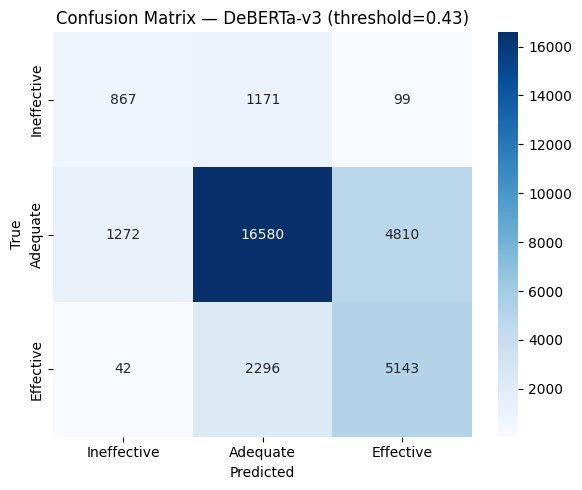

In [15]:
cm = confusion_matrix(test_labels, test_preds_calibrated)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Ineffective", "Adequate", "Effective"],
    yticklabels=["Ineffective", "Adequate", "Effective"]
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title(f"Confusion Matrix — DeBERTa-v3 (threshold={best_threshold:.2f})")
plt.tight_layout()
plt.show()

In [16]:
# Save results
test_results = test_df.reset_index(drop=True).copy()
test_results["true_label"]      = test_labels
test_results["pred_label"]      = test_preds_calibrated
test_results["true_label_name"] = test_results["true_label"].map(id2label)
test_results["pred_label_name"] = test_results["pred_label"].map(id2label)
test_results["prob_ineffective"] = test_probs[:, 0]
test_results["prob_adequate"]    = test_probs[:, 1]
test_results["prob_effective"]   = test_probs[:, 2]

test_results.to_csv("deberta_test_predictions.csv", index=False)
test_results.head()

,full_text,discourse_text,discourse_type,discourse_effectiveness,label,true_label,pred_label,true_label_name,pred_label_name,prob_ineffective,prob_adequate,prob_effective
0,Phones & Driving Essay\n\nI believe that drive...,I believe that drivers shouldn't use cell phon...,Position,Adequate,1,1,1,Adequate,Adequate,0.028929,0.898634,0.072438
1,Phones & Driving Essay\n\nI believe that drive...,it is an attention hazzard. Driving with your ...,Claim,Adequate,1,1,2,Adequate,Effective,0.000045,0.156329,0.843626
2,Phones & Driving Essay\n\nI believe that drive...,there are apps and programs on the phones that...,Claim,Adequate,1,1,1,Adequate,Adequate,0.002405,0.741131,0.256465
3,Phones & Driving Essay\n\nI believe that drive...,"First and foremost, Driving without the phone ...",Claim,Adequate,1,1,2,Adequate,Effective,0.000048,0.419621,0.580330
4,Phones & Driving Essay\n\nI believe that drive...,Not only will it save you life and everyone el...,Evidence,Adequate,1,1,1,Adequate,Adequate,0.000989,0.668922,0.330089


In [17]:
model.save_pretrained("./deberta_saved_model")
tokenizer.save_pretrained("./deberta_saved_model")

('./deberta_saved_model\\tokenizer_config.json',
 './deberta_saved_model\\special_tokens_map.json',
 './deberta_saved_model\\spm.model',
 './deberta_saved_model\\added_tokens.json',
 './deberta_saved_model\\tokenizer.json')